In [85]:
from qat.fermion.hamiltonians import FermionHamiltonian, SpinHamiltonian
from qat.fermion.hamiltonians import make_anderson_model
from qat.fermion.trotterisation import make_trotterisation_routine
from qat.lang import *
from qat.core import Term, Schedule, Variable, Observable
from qat.qpus import get_default_qpu
from qat.plugins import ScipyMinimizePlugin
from scipy.optimize import minimize
from qat.lang.AQASM import Program, QRoutine

import numpy as np
import numpy.typing as npt

import matplotlib.pyplot as plt
from collections import deque

from scipy.optimize import minimize

On commence d'abord par définir l'opérateur $c^{\dagger}_{i, \sigma1}c_{j, \sigma2}$ qui va être utilisé pour définir le hamiltonien :

In [86]:
#Definition de l'operateur  
def couplingOp(n_qubits: int, energy: float, i: int, j: int, spin_i: str, spin_j: str) : 
    """ Calcule une instance de FermionHamiltonian associée à l'opérateur c^{dagger}_{i, sigma1}c_{j, sigma2}, 
    i et j sont les numéros de site, energy est le préfacteur énergétique apparaissant dans 
    la définition du hamiltonien. """
    if spin_i == "+" :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i, j])])
    else :
         if spin_j == "-" :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j+1])])
         else :
            return FermionHamiltonian(n_qubits, [Term(energy, "Cc", [i+1, j])]) 
        
def nOp(n_qubits, energy, i, spin) :
    """Calcule une instance de FermionHamiltonian associée à l'opérateur n_{i, spin} avec le préfacteur energy."""
    return couplingOp(n_qubits, energy, i, i, spin, spin)
    

In [87]:
print(couplingOp(4,2,1,2,"+","-"))
print((couplingOp(4,1,0,0,"-","-")))


2 * (Cc|[1, 3])
1 * (Cc|[1, 1])


Definition de l'Hamiltonien de Anderson (avec la possibilité de choisir le nombre d'impuretés contrairement à la fonction make_anderson_model de myQLM)

In [88]:
#Definition de l'hamiltonien
def hamiltonian(n_impurities: int, n_bain: int, U: float, mu: float, t: float, V, epsilon: list) :
    """ Calcule le hamiltonien du modèle d'Anderson et le renvoie sous la forme 
    du couple (SpinHamiltonian, matrice associée)."""
    n_qubits = 2 * n_bain + 2 * n_impurities
    H_repulsion = 0
    H_hopping = 0
    H_chem = 0
    for wire in range(0, 2*n_impurities, 2) :
        #Calcul du terme de potentiel chimique
        H_chem += nOp(n_qubits, -mu, wire, "+")
        H_chem += nOp(n_qubits, -mu, wire, "-")

        #Calcul du terme d'effet tunnel entre impuretés, dit "hopping"
        for wire2 in range(0, 2*n_impurities, 2) :
            if wire2 != wire :
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "+", "+")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "-")
                H_hopping += couplingOp(n_qubits, -t, wire, wire2, "-", "+")
            else :
                #Calcul du terme de répulsion coulombienne
                H_repulsion += nOp(n_qubits, U, wire, "+")*nOp(n_qubits, 1, wire,"-")
    
    H_impurity_bath = 0
    H_bath = 0
    for wire3 in range(2*n_impurities, n_qubits, 2) :
        i = (wire3 - 2*n_impurities) // 2
        e = epsilon[i]
        #Calcul du terme lié au bain
        H_bath += nOp(n_qubits, e, wire3, "+")
        H_bath += nOp(n_qubits, e, wire3, "-")
        
        for wire4 in range(0, 2*n_impurities, 2) :
            #Calcul du terme d'interaction impureté-bain
            j = wire4 // 2
            v = V[j][i]
            vstar = v if np.isreal(v) else np.conj(v)
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "+", "+") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "+", "+")
            
            H_impurity_bath += couplingOp(n_qubits, v, wire4, wire3, "-", "-") 
            H_impurity_bath += couplingOp(n_qubits, vstar, wire3, wire4, "-", "-")
        

    H_anderson = H_repulsion + H_chem + H_impurity_bath + H_bath + H_hopping
    H_spin = H_anderson.to_spin(method = "jordan-wigner")#Fermion to Qubit
    return H_spin, H_spin.get_matrix()

AndersonHamiltonian, matrix = hamiltonian(1, 1, 0, 4, 3, [[1]], [0]) 
for term in (AndersonHamiltonian.terms) :
    print(term.op , term.qbits)
print(AndersonHamiltonian.terms[0])

Z [0]
Z [1]
XZX [0, 1, 2]
YZY [0, 1, 2]
XZX [1, 2, 3]
YZY [1, 2, 3]
Term(qbits=[0], op='Z', _coeff=TNumber(is_abstract=False, type=5, int_p=None, double_p=None, string_p=None, matrix_p=None, serialized_p=None, complex_p=ComplexNumber(re=2.0, im=0.0)), _do_validity_check=True)


In [89]:
#Test de correspondance avec la fonction de MyQLM pour une impureté
AndersonHamiltonian, matrix = hamiltonian(1, 1, 2, 4, 3, [[2]], [4]) 
AndersonHamiltonian1, matrix1 = hamiltonian(1, 3, 3, 2, 1, [[2, 1, 5]], [1,0, 4])
qlmA = make_anderson_model(2, 4, [2], [4]).to_spin()
qlmB = make_anderson_model(3, 2, [2, 1, 5], [1, 0, 4]).to_spin()
print(AndersonHamiltonian == qlmA)
print(qlmB == AndersonHamiltonian1)

True
True


In [90]:
rou = QRoutine()
rou.apply(X, 0)

H_test= SpinHamiltonian(4, [Term(1, "ZXY", [1, 2, 3]), Term(1, "XY",[0, 1])])
print(H_test)


1 * (ZXY|[1, 2, 3]) +
1 * (XY|[0, 1])


Avant toute chose, il faut implémenter une façon de calculer une exponentielle complexe d'une chaîne de Pauli (Pauli string), pour cela on met en place des transformations qui permettent à se ramener à des mots de Pauli uniquement avec des matrices Zi, dont l'exponentielle complexe peut s'implémenter grâce à des CNOT et des rotations d'axe Z, on a en particulier :
$$R_{Yq}\left(\frac{\pi}{2}\right) Z_q R_{Yq}^\dagger\left(\frac{\pi}{2}\right) = X_q$$
$$
R_{Yq}\left(\frac{\pi}{2}\right) e^{-i\theta Z_0 \dots Z_q \dots Z_N} R_{Yq}^\dagger\left(\frac{\pi}{2}\right) =
e^{-i\theta Z_0 \dots X_q \dots Z_N}
$$
$$
R_{Xq}\left(-\frac{\pi}{2}\right) Z_q R_{Xq}^\dagger\left(-\frac{\pi}{2}\right) = Y_q
$$
$$
R_{Xq}\left(-\frac{\pi}{2}\right) e^{-i\theta Z_0 \dots Z_q \dots Z_N} R_{Yq}^\dagger\left(-\frac{\pi}{2}\right) =
e^{-i\theta Z_0 \dots Y_q \dots Z_N}
$$


In [ ]:
def expPauli(term, t) :
    before = deque() #pile des rotations qui s'executeront avant le calcul de l'exponentielle de matrice
    after = deque() #file des rotations qui s'executeront après le calcul de l'exponentielle de matrice
    CNOTqueue= deque() #file des CNOT qui relieront les matrices Zi en amont

    rout = QRoutine() #initialize a routine 
    
    pauliString, nq = term.op, term.qbits #nq[i] is the qubit upon which pauliString[i] acts
    n = len(pauliString)
    for i in range(n-1) :
        CNOTqueue.append((CNOT, [i, n - 1]))
        if pauliString[i] == "X" :
            before.append((RY(np.pi / 2),i))
            after.append((RY(- np.pi / 2),i))
        elif pauliString[i] == "Y" :
            before.append((RX(-np.pi / 2),i))
            after.append((RX(np.pi / 2),i))
    
    if pauliString[n - 1] == "X" :
        before.append((RY(np.pi / 2), n - 1))
        after.append((RY(- np.pi / 2), n - 1))
    elif pauliString[n - 1] == "Y" :
        before.append((RX(-np.pi / 2), n - 1))
        after.append((RX(np.pi / 2), n - 1))

    
    CNOTstack = CNOTqueue.copy() #pile des CNOT qui relieront les matrices Zi en aval

    while len(before) > 0 :
        rout.apply(*before.pop())
    while len(CNOTqueue) > 0 :
        rout.apply(*CNOTqueue.popleft())

    rout.apply(RZ(-2*t), n - 1)

    while len(CNOTstack) > 0 :
        rout.apply(*CNOTstack.pop())
    while len(after) > 0 :
        rout.apply(*after.popleft())
    
    return rout, nq

r, q= expPauli(AndersonHamiltonian.terms[4], 3)
print(q)
r.display()


[0, 1, 2]


<h3>Maintenant on implémente une routine de Trotterization, celle-ci doit aussi renvoyer les qubits sur lesquels agit la routine afin de pouvoir l'utiliser comme module pour construire d'autres circuits</h3>

In [120]:
def trotterization(h, N, t) :
    rout = QRoutine()
    qubitsAffectés = []
    for i in range(N) :
        for term in h.terms :
            gate, qubitsActedOn = expPauli(term, t/N)
            rout.apply(gate, qubitsActedOn)
            for j in qubitsActedOn :
                if j not in qubitsAffectés :
                    qubitsAffectés.append(j) 
    return rout, sorted(qubitsAffectés)


trotterCirc, qubitsAffectés = trotterization(H_test, 2, 1)
print(qubitsAffectés)
trotterCirc.display()


[0, 1, 2, 3]


In [121]:
job = trotterCirc.to_job()
job1= make_trotterisation_routine(AndersonHamiltonian, 2, 1).to_job()
result = get_default_qpu().submit(job)
result1 = get_default_qpu().submit(job1)
for sample in result:
    print(sample.state, sample.probability)

for sample in result1 :
    print(sample.state, sample.probability)

|0000> 0.03469487252568744
|0011> 0.41998156802895403
|1100> 0.41998156802895376
|1111> 0.12534199141640487
|0000> 0.9999999999999973


<h3>Implementation du HVA pour passer d'un hamiltonien connu (diagonalisable) à notre hamiltonien d'Anderson</h3>

In [93]:
def hva_ansatz(psi0, depth, hamiltonians,
                h_target, n_steps,  params) : #prend des hamiltoniens de spin et simule un recuit quantique
    rout = QRoutine()
    k = len(hamiltonians)
    rout.apply(psi0, 0)
    for i in range(depth) :
        for j in range(k) :
            rout1, qubitsModified1 = trotterization(hamiltonians[j], n_steps, -params[depth*i + j])
            rout.apply(rout1, qubitsModified1)
            rout2, qubitsModified2 = trotterization(h_target, n_steps, -params[depth*i + k])
            rout.apply(rout2, qubitsModified2)
    return rout

def cost_function(psi0, depth, hamiltonians,
                h_target, n_steps,  params) :
    
    job = hva_ansatz(psi0, depth, hamiltonians,
                h_target, n_steps,  params).to_job(observable = h_target)
    qpu = get_default_qpu()
    result = qpu.submit(job)
    return result.value

initial_params = np.random.random(2)
variational_circuit = lambda params: cost_function(rou, 1, [H_test], AndersonHamiltonian, 1, params)

ground_state_energy = minimize(variational_circuit, x0 = initial_params)
print("énergie avant optimisation, avec paramètres aléatoires", variational_circuit(initial_params))
print("l'énergie du fondamental :", ground_state_energy.fun)
print("paramètres :", ground_state_energy.x)



énergie avant optimisation, avec paramètres aléatoires -0.06854346971159853
l'énergie du fondamental : -2.5642255405209156
paramètres : [1.57079647 0.65193765]


<h2>Ça marche !!!</h2> (à tester toutefois avec un vrai état fondamental en entrée)

Il faut aussi prendre en compte les termes d'annihilation et de création, puisqu'ils ne sont pas unitaires, on les décompose comme sommes d'unitaire avec la transformation de Jordan-Wigner, on a : 
$$
c_{i,\uparrow} = \frac{1}{2} \left(X_{2i} + i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow} = \frac{1}{2} \left(X_{2i+1} + i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$
$$
c_{i,\uparrow}^{\dagger} = \frac{1}{2} \left(X_{2i} - i Y_{2i} \right) \prod_{j<2i} Z_j
$$
$$
c_{i,\downarrow}^{\dagger} = \frac{1}{2} \left(X_{2i+1} - i Y_{2i+1} \right) \prod_{j<2i+1} Z_j
$$

On a aussi $iY = RY(-\pi) = \begin{pmatrix}
0 & 1 \\
-1 & 0
\end{pmatrix}
$ and $-iY = RY(\pi)$

Maintenant on code un circuit correspondant à $c_{j,\sigma}(t)$ and $c_{i, \sigma'}^{\dagger}(0)$ 

In [94]:
def cMapping(index, spin) : 
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(-np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y
    

In [95]:
def cDagMapping(index, spin) :
    '''index commence à 0, repésente soit une impureté (0 <= index<= nb impuretés - 1) soit un mode de bain 5(nb impuretés <= index<= nb qubits - 1'''
    routX = QRoutine()
    routY = QRoutine()
    qubitsActedOn_X = []
    qubitsActedOn_Y = []
    if spin == "+" :
        routX.apply(X, 2*index)
        routY.apply(RY(np.pi), 2*index) #+iY
        
        for wire in range(2 * index) : 
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index)
        qubitsActedOn_Y.append(2*index)

    else : #spin down
        routX.apply(X, 2*index + 1)
        routY.apply(RY(-np.pi), 2*index + 1)
        for wire in range(2 * index + 1) :
            routX.apply(Z, wire)
            qubitsActedOn_X.append(wire)
            routY.apply(Z, wire)
            qubitsActedOn_Y.append(wire)

        qubitsActedOn_X.append(2*index + 1)
        qubitsActedOn_Y.append(2*index + 1)
            
    return routX, qubitsActedOn_X, routY, qubitsActedOn_Y

routX, qubitsActedOn_X, routY, qubitsActedOn_Y = cDagMapping(1, "+")
routX.display()
routY.display()


In [96]:
routX, a, routY, b = cMapping(0, "-")
routX.display()
routY.display()


In [97]:
AndersonHamiltonian2, matrix2 = hamiltonian(1, 1, 0, 0, 0, [[1]], [1])
print(AndersonHamiltonian2)

(1+0j) * I^4 +
(0.5+0j) * (XZX|[0, 1, 2]) +
(0.5+0j) * (YZY|[0, 1, 2]) +
(0.5+0j) * (XZX|[1, 2, 3]) +
(0.5+0j) * (YZY|[1, 2, 3]) +
(-0.5+0j) * (Z|[2]) +
(-0.5+0j) * (Z|[3])


XYarray (2 element array) ci-dessous se réfère à ce que nous calculons, soit la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_i$, et la chaîne de Pauli qui comporte un X ou celle qui comporte un Y pour $c_j^{\dagger}$ pour le calcul des matrices unitaires dont la somme nous donne la fonction de Green. Par exemple, si XYarray = ["X", "Y"], nous calculons $e^{i H t} (X_{2i} \prod_{j<2i} Z_j) e^{- i H t}(-iY_{2i} \prod_{j<2i} Z_j)$ (si les deux spins sont vers le haut).

In [98]:
def circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    rout = QRoutine()

    routX_c, qubitsX, routY_c, qubitsY = cMapping(i, sigma_i)
    routX_cdag, qubitsX_dag, routY_cdag, qubitsY_dag = cDagMapping(j, sigma_j)
    rout.apply(*trotterization(h, N, t))

    if XYarray[0] == "X" :
        rout.apply(routX_c, qubitsX)
    else :
        rout.apply(routY_c, qubitsY)

    rout.apply(*trotterization(h, N, -t))#Trotterization avec -H
    
    if XYarray[1] == "X" : #optimisation future circuitX_cdag = circuitX_c
        rout.apply(routX_cdag, qubitsX_dag)
    else :
        rout.apply(routY_cdag, qubitsY_dag)

    return rout


circuitGreen(0, "-", 0, "+", AndersonHamiltonian2, 3, 1, ["X","Y"]).display()

Il reste à calculer la moyenne $\exp{(iHt)} c_{j,\sigma} \exp{(-iHt)} c_{i, \sigma'}^{\dagger} \ket{\psi_{0}}$ and $\ket{\psi_{0}}$ avec un test de Hadamard. Pour cela on construit une porte controle U où U est la fonction entre le bra et le ket dans la fonction de Green :

In [99]:
def controlU(i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    routine = circuitGreen(i, sigma_i, j, sigma_j, h, t, N, XYarray)
    return routine.ctrl()
    
U = controlU(0, "-", 0, "+", AndersonHamiltonian2, 3, 1, ["X","Y"])
rout = QRoutine()
rout.apply(U, 0, [i for i in range(1, 5)])

rout.display()

In [100]:

def realHTest(n_qubits, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    prog = Program()
    qubits = prog.qalloc(n_qubits + 1) #we add an ancilla qubit
    prog.apply(H, qubits[0])
    #il reste à initialiser l'état fondamental sur lequel agit U
    prog.apply(controlU(i, sigma_i, j, sigma_j, h, t, N, XYarray), qubits[0], qubits[1:n_qubits + 1])
    prog.apply(H, qubits[0])

    circuit = prog.to_circ()
    return circuit

def imHTest(n_qubits, i, sigma_i, j, sigma_j, h, t, N, XYarray) :
    prog = Program()
    qubits = prog.qalloc(n_qubits + 1) #we add an ancilla qubit
    prog.apply(H, qubits[0])
    prog.apply(S.dag(), qubits[0])
    #il reste à initialiser l'état fondamental sur lequel agit U
    prog.apply(controlU(i, sigma_i, j, sigma_j, h, t, N, XYarray), qubits[0], qubits[1:n_qubits + 1])
    prog.apply(H, qubits[0])

    circuit = prog.to_circ()
    return circuit

imHTest(4, 0, "-", 0, "+", AndersonHamiltonian2, 3, 1, ["X","Y"]).display()



In [101]:
prog = QRoutine()
routine = QRoutine()
a = make_trotterisation_routine(AndersonHamiltonian2, n_trotter_steps=2, final_time=1)
print(a.__dict__)
routine.apply(a,[range(4)])
control = routine.ctrl()

prog.apply(H, 0)
prog.apply(S.dag(), 0)
prog.apply(control, [0,1,2,3,4])
prog.apply(H, 0)
circuit = prog.to_circ()
qpu = get_default_qpu()
job = circuit.to_job(observable = Observable(5, pauli_terms=[Term(1, 'Z', [0])]))
result = qpu.submit(job)
print(2*result.value - 1)


{'name': None, 'arity': 4, 'matrix': None, 'subgate': None, 'nb_ctrls': None, 'is_dag': False, 'is_conj': False, 'is_trans': False, 'compute_stack': [], 'op_list': [<qat.lang.AQASM.routines._RoutOp object at 0x0000018E0DD37650>, <qat.lang.AQASM.routines._RoutOp object at 0x0000018E0DD35880>], 'max_wire': 3, 'ancillae': set(), 'freed_ancillae': set(), 'lock_release_operations': [], 'variables': []}
0.6829419696157899


In [105]:
def imagGreenFunction(n_qubits, i, sigma_i, j, sigma_j, h, t, N) :
    qpu = get_default_qpu()
    imaginaryPart = 0
    arrays = [['X','X'],['X','Y'],['Y','X'],['Y','Y']]
    for XYarray in arrays :
            circuit = imHTest(n_qubits, i, sigma_i, j, sigma_j, h, t, N, XYarray)
            job = circuit.to_job(observable = Observable(n_qubits + 1, pauli_terms=[Term(1, 'Z', [0])]))
            result = qpu.submit(job)
            imaginaryPart += 2*result.value - 1
    return imaginaryPart


print(imagGreenFunction(4, 0, "-", 0, "+", AndersonHamiltonian2, 3, 1))
    

-4.0


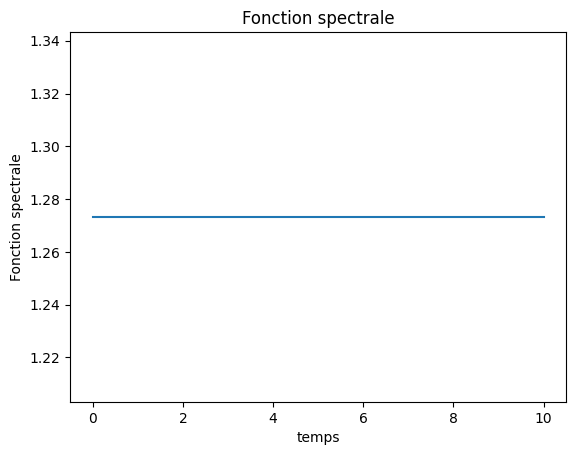

In [103]:
def spectralFunction(n_qubits, i, sigma_i, j, sigma_j, h, timeArray, N) :
    evolution = []
    for t in timeArray :
        value = imagGreenFunction(n_qubits, i, sigma_i, j, sigma_j, h, t, N)
        evolution.append(-value/np.pi)
    return evolution

time = np.linspace(0, 10, 20)
evolution = spectralFunction(4, 0, "-", 0, "+", AndersonHamiltonian2, time, 1)
plt.plot(time, evolution)
plt.xlabel("temps")
plt.ylabel("Fonction spectrale")
plt.title("Fonction spectrale")
plt.show()



<h1>!! A FAIRE !!</h1>
<h2> Ajouter un module pour initialiser à psi0 le circuit calculant la fonction de Green</h2>
<h2>Régler la fonction de trotterization qui ne marche pas lorsque l'hamiltonien n'agit pas sur tous les qubits</h2>

<h2>TESTS</h2>


In [104]:
def G_Lehman(valeurs_prop: np.ndarray[float], vecteurs_prop: np.ndarray[float], beta: float, n_site_bain, omegas):
    n_site = n_site_bain + 1
    dim, nb_vp = np.shape(vecteurs_prop)
    N = len(omegas)
    valeurs_prop = valeurs_prop - valeurs_prop[0]
    resu = np.zeros(N,dtype = 'complex_')
    Z = np.sum(np.exp(-beta*(valeurs_prop)))
    S = 0
    somme_coef = 0
    for i in range(nb_vp):
        for j in range(nb_vp):
            prod_scal = 0
            for k in range(2**(2*n_site - 1)):
                sig_k = 2*k + 1
                prod_scal += vecteurs_prop[sig_k, j].conj() * vecteurs_prop[2*k, i]
            prod_scal = np.real(prod_scal)**2 + np.imag(prod_scal)** 2
            somme_coef += (np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal
            for n in range(N):
                resu[n] += ((np.exp(-beta*valeurs_prop[i]) + np.exp(-beta*valeurs_prop[j])) * prod_scal ) / (
                        valeurs_prop[j] - valeurs_prop[i] - 1j * omegas[n])
    return -resu/Z
